In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 15
TS = 0.07

In [2]:
TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
SCALER = joblib.load("./scalers/scaler.pkl")    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [3]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,...,R2_Val_2_Theta,MSE_Val_2_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_LSG_1_Theta,MSE_LSG_1_Theta,R2_LSG_2_Theta,MSE_LSG_2_Theta
0,model_arch16_r0.01_Ld0.3_Lp0.7_seed3977,[16],0.3,0.7,0.01,3977,0.877719,0.027735,0.727107,0.059998,...,0.828034,0.039386,0.750613,0.081873,0.366026,0.206816,0.694678,0.120493,0.166207,0.270584
1,model_arch16_r0.01_Ld0.3_Lp0.7_seed356,[16],0.3,0.7,0.01,356,0.830978,0.038337,0.830777,0.037205,...,0.882704,0.026864,0.609243,0.128285,0.219075,0.254755,0.788692,0.083391,0.316014,0.221968
2,model_arch16_r0.01_Ld0.3_Lp0.7_seed1803,[16],0.3,0.7,0.01,1803,0.511322,0.110839,0.600838,0.087759,...,0.791485,0.047756,-0.051957,0.345356,-1.992733,0.976296,-0.000198,0.394720,-0.737380,0.563817
3,model_arch16_r0.01_Ld0.3_Lp0.7_seed5410,[16],0.3,0.7,0.01,5410,0.852796,0.033388,0.528128,0.103745,...,0.546055,0.103968,0.629751,0.121552,0.121723,0.286514,0.468447,0.209773,-0.558195,0.505668
4,model_arch16_r0.01_Ld0.3_Lp0.7_seed6545,[16],0.3,0.7,0.01,6545,0.599440,0.090853,0.673883,0.071700,...,0.890229,0.025141,-0.145089,0.375931,-0.632824,0.532663,0.215326,0.309665,-0.520671,0.493490


In [4]:
def PickModels(target, threshold=0.5):

    # 🔹 lê arquivo
    df = pd.read_excel("BestModels.xlsx")

    # 🔹 cria TODAS as colunas de R2 automaticamente
    r2_cols = [f"R2_{t}_{target}" for t in TITLES if f"R2_{t}_{target}" in df.columns]

    # =========================
    # 🔥 FILTRO GLOBAL
    # =========================
    
    filtered = df[(df[r2_cols] >= threshold).all(axis=1)].copy()

    print(f"Modelos após filtro R2 >= {threshold}: {len(filtered)}")

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # =========================
    # 🔹 NORMALIZAR ARQUITETURA
    # =========================
    
    filtered["Neurons_str"] = filtered["Neurons"].apply(lambda x: str(x))

    # =========================
    # 🔥 REMOVER DUPLICADOS (MESMA ARQUITETURA)
    # =========================
    
    val_col1 = f"R2_Val_2_{target}"
    val_col2 = f"R2_Val_1_{target}"

    filtered = filtered.sort_values(
        by=[val_col1, val_col2],
        ascending=[False, False]
)

    # mantém só o melhor de cada arquitetura
    filtered_unique = filtered.drop_duplicates(subset="Neurons_str", keep="first")

    print(f"Modelos após remover arquiteturas repetidas: {len(filtered_unique)}")

    # =========================
    # 🔹 ORDENAÇÃO FINAL
    # =========================
    
    test_cols = [c for c in r2_cols if "Test" in c]
    train_cols = [c for c in r2_cols if "Train" in c]

    filtered_unique["R2_test_mean"] = filtered_unique[test_cols].mean(axis=1)
    filtered_unique["R2_train_mean"] = filtered_unique[train_cols].mean(axis=1)

    filtered_unique = filtered_unique.sort_values(
        by=[val_col1, val_col2, "R2_test_mean", "R2_train_mean"],
        ascending=False
    )

    # =========================
    # 🔥 TABELA FINAL
    # =========================
    
    final_cols = ["model", "Neurons"] + r2_cols

    final_table = filtered_unique[final_cols]

    print("\n📊 MODELOS FINAIS (SEM ARQUITETURAS REPETIDAS)")
    display(final_table)

    return final_table

In [5]:
def LoadModelFromRow(row):

    model_name = row["model"]

    model_path = f"models/{model_name}.keras"
    model = tf.keras.saving.load_model(model_path)

    return model

In [6]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [7]:
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [8]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=0.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)

    fig, axs = plt.subplots(
        n_datasets,
        2 * n_targets,
        figsize=(6 * 2 * n_targets, 4 * n_datasets)
    )

    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val_1": [], "R2_Val_2": [],
            "R2_Test_1": [], "R2_Test_2": [], 
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val_1": [], "MSE_Val_2": [],
            "MSE_Test_1": [], "MSE_Test_2": [], 
            "MSE_LSG_1": [], "MSE_LSG_2": [],
        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        dy_pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(dy_pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

        # =========================
        # MÉTRICAS + PLOTS
        # =========================
        for j, name in enumerate(TARGET_INT):

            # métricas (posição)
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, MSE = {mse:.4e}")

            # 🔹 coluna da posição (y)
            ax_y = axs[i, j] if n_datasets > 1 else axs[j]
            PlotOut(
                ax_y,
                TITLES[i],
                f"{name}",
                y_true[:, j],
                y_pred[:, j],
                y_cin[:, j]
            )

            # 🔹 coluna da derivada (dy)
            ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
            PlotOut(
                ax_dy,
                TITLES[i],
                f"d{name}",
                dy_true[:, j],
                dy_pred[:, j],
                dy_cin[:, j]
            )

    plt.tight_layout()
    return metrics

In [18]:
rows = PickModels("Theta", 0.4)

Modelos após filtro R2 >= 0.4: 2
Modelos após remover arquiteturas repetidas: 2

📊 MODELOS FINAIS (SEM ARQUITETURAS REPETIDAS)


,model,Neurons,R2_Train_1_Theta,R2_Train_2_Theta,R2_Val_1_Theta,R2_Val_2_Theta,R2_Test_1_Theta,R2_Test_2_Theta,R2_LSG_1_Theta,R2_LSG_2_Theta
0,model_arch16_r0.01_Ld0.7_Lp0.3_seed5410,[16],0.774572,0.493019,0.939161,0.679519,0.591210,0.715744,0.484367,0.844647
1,model_arch16-8_r0.9_Ld0.3_Lp0.7_seed6545,"[16, 8]",0.821504,0.724402,0.893724,0.570374,0.475021,0.812831,0.448839,0.819893


Theta | Train_1 -> R² = 0.7746, MSE = 5.1130e-02
Theta | Train_2 -> R² = 0.4930, MSE = 1.1146e-01
Theta | Val_1 -> R² = 0.9392, MSE = 1.3959e-02
Theta | Val_2 -> R² = 0.6795, MSE = 7.3400e-02
Theta | Test_1 -> R² = 0.5912, MSE = 1.3421e-01
Theta | Test_2 -> R² = 0.7157, MSE = 9.2731e-02
Theta | LSG_1 -> R² = 0.4844, MSE = 2.0349e-01
Theta | LSG_2 -> R² = 0.8446, MSE = 5.0415e-02
Theta | Train_1 -> R² = 0.8215, MSE = 4.0486e-02
Theta | Train_2 -> R² = 0.7244, MSE = 6.0593e-02
Theta | Val_1 -> R² = 0.8937, MSE = 2.4384e-02
Theta | Val_2 -> R² = 0.5704, MSE = 9.8398e-02
Theta | Test_1 -> R² = 0.4750, MSE = 1.7235e-01
Theta | Test_2 -> R² = 0.8128, MSE = 6.1059e-02
Theta | LSG_1 -> R² = 0.4488, MSE = 2.1751e-01
Theta | LSG_2 -> R² = 0.8199, MSE = 5.8449e-02


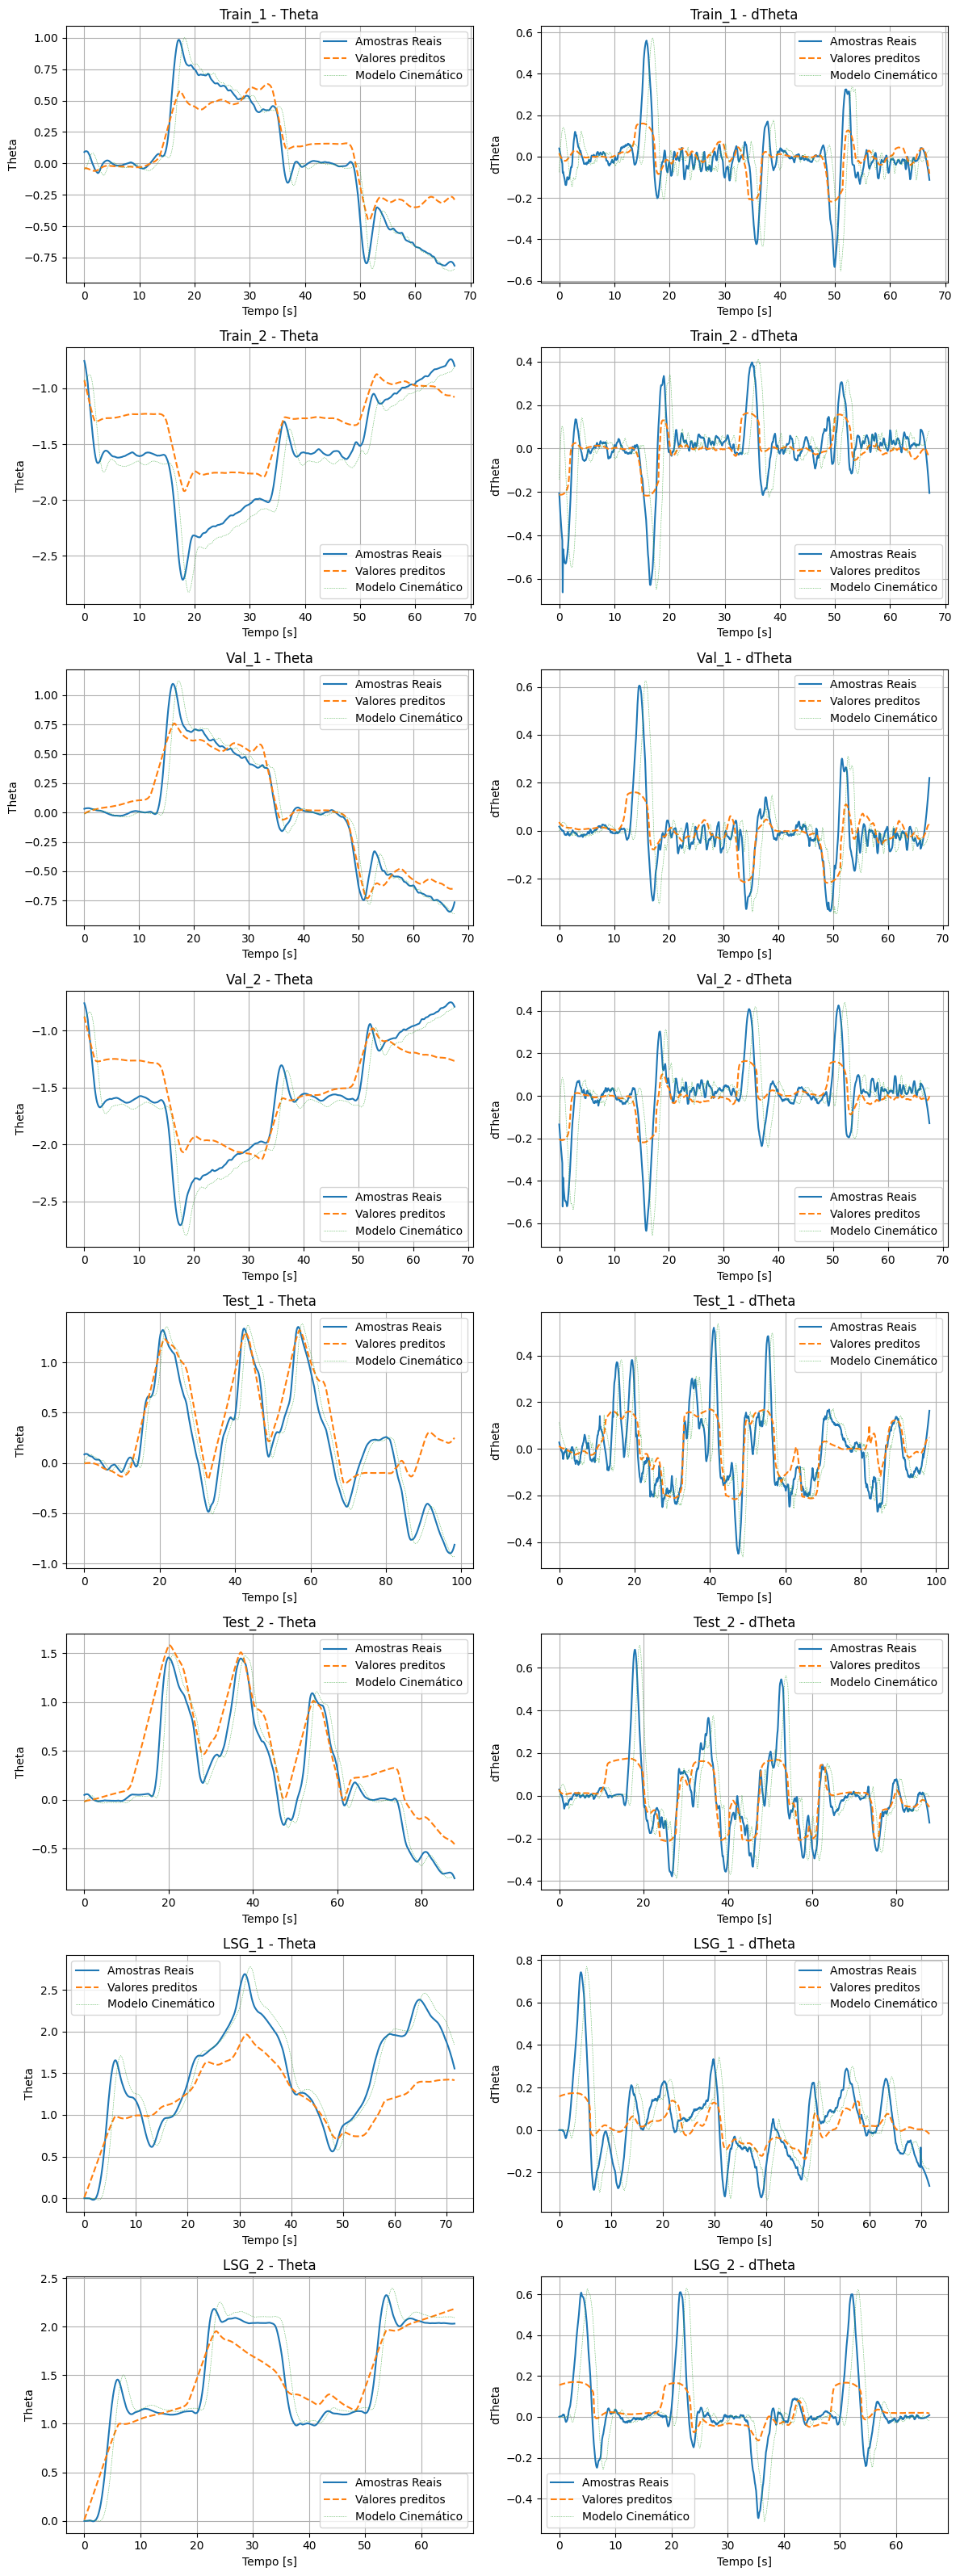

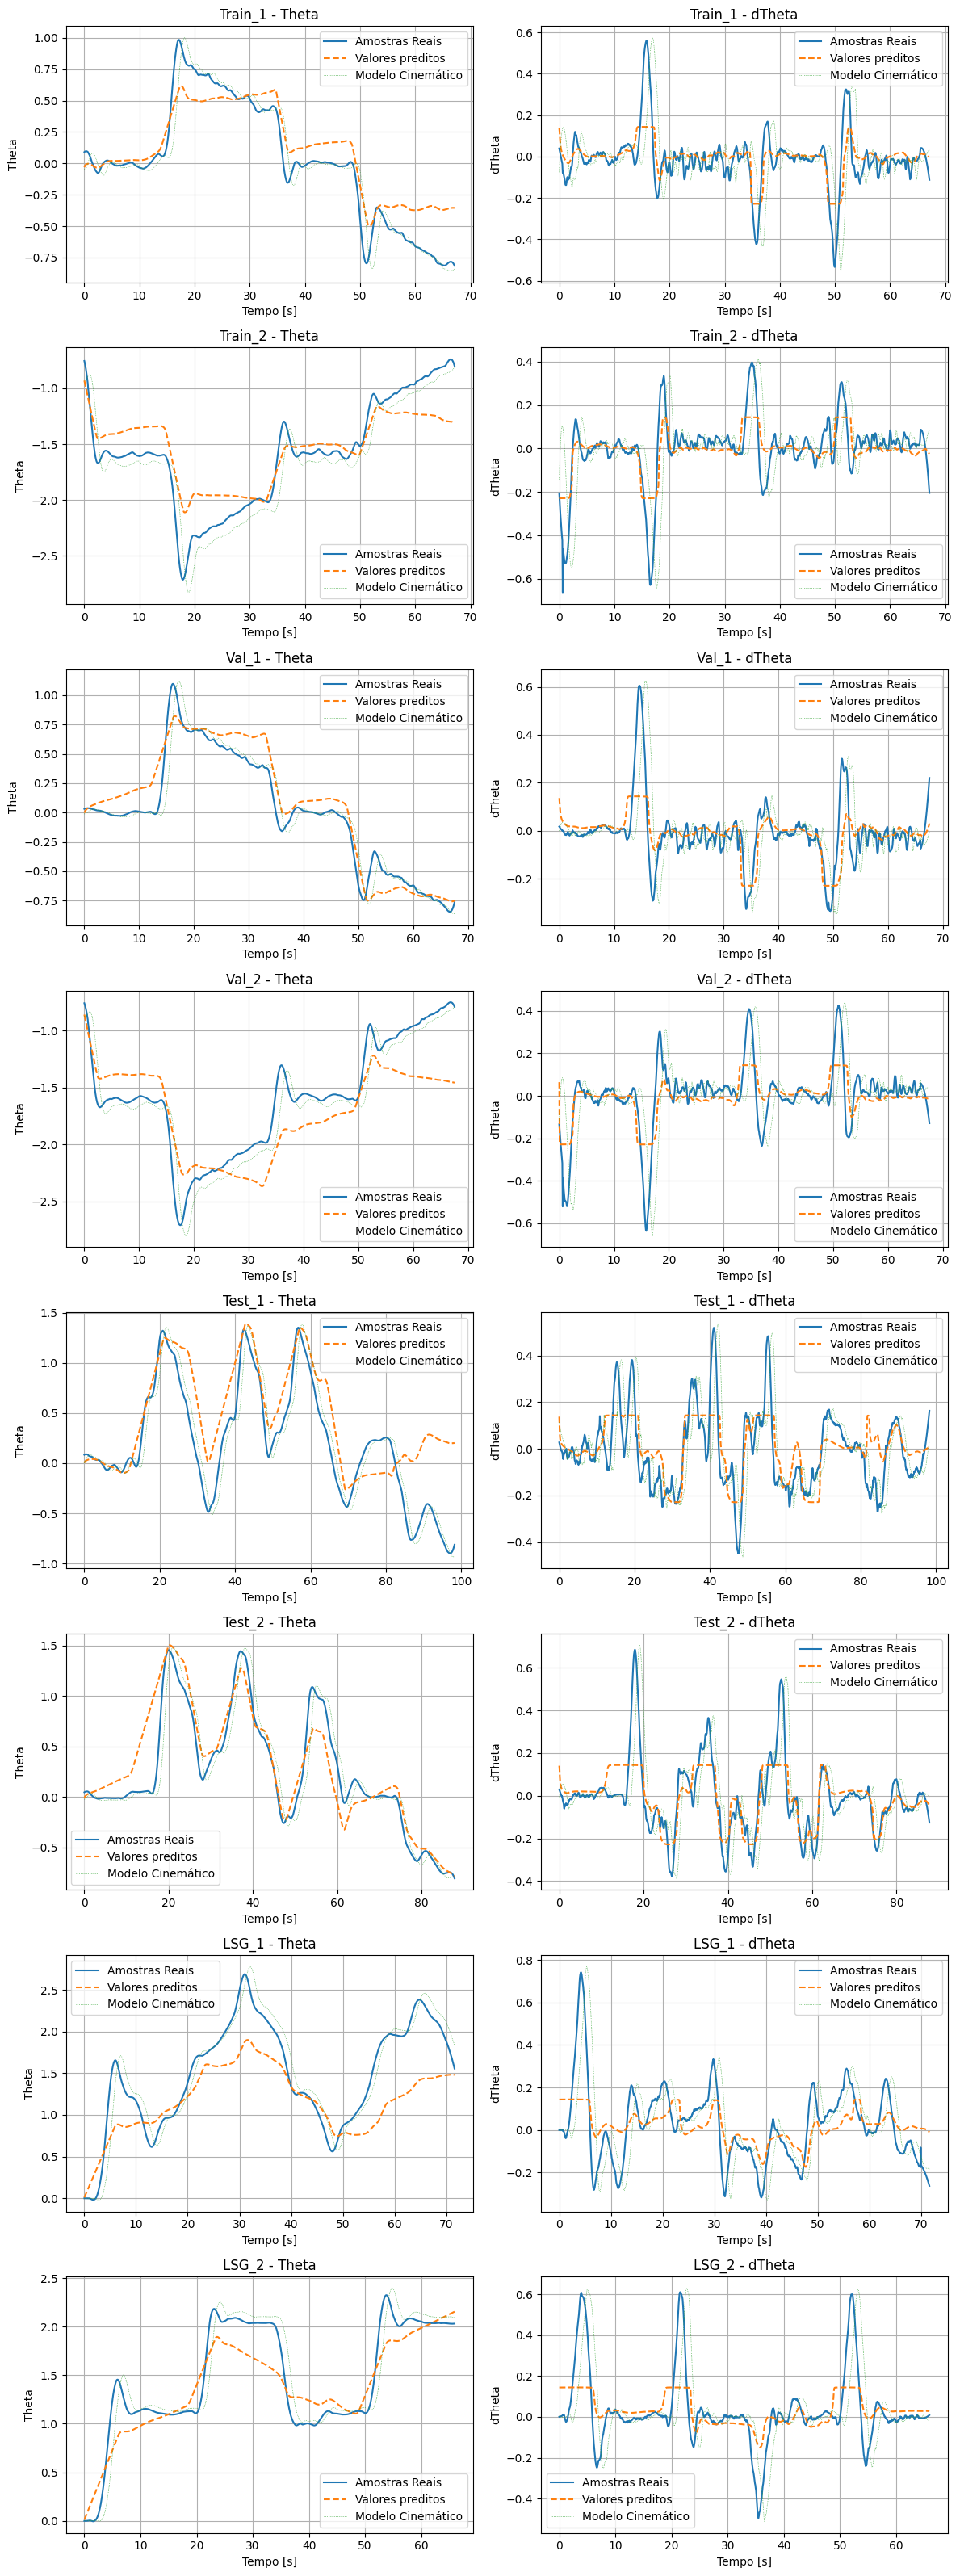

In [19]:
for i in range(len(rows)):
    row = rows.iloc[i]
    model = LoadModelFromRow(row)
    metrics = EvalModel(model)

In [20]:
def ExportPredictionsExcel(models_dict, filename="predicoes.xlsx"):

    writer = pd.ExcelWriter(filename, engine="openpyxl")

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x_seq, y_seq = CreateSequences(x, y, TIME_STEPS)

        time = (np.arange(0, len(x_seq), 1) * TS).round(5)

        y_true = y_seq

        # modelo cinemático
        y_cin, dy_cin = GetCin(Datasets[i])
        y_cin = y_cin[:y_true.shape[0]]

        df = pd.DataFrame({
            "Tempo": time
        })

        # =========================
        # ENTRADAS
        # =========================
        for col in PREDICTORS:
            df[col] = Datasets[i][col].iloc[TIME_STEPS:].values

        # =========================
        # SAÍDA REAL
        # =========================
        for j, name in enumerate(TARGET_INT):
            df[f"{name}_real"] = y_true[:, j]

        # =========================
        # MODELO CINEMÁTICO
        # =========================
        for j, name in enumerate(TARGET_INT):
            df[f"{name}_cin"] = y_cin[:, j]

        # =========================
        # MODELOS TREINADOS
        # =========================
        for model_name, model in models_dict.items():

            dy_pred = model(tf.convert_to_tensor(x_seq, dtype=tf.float32)).numpy()
            dy_pred = OUT_SCALER.inverse_transform(dy_pred)

            y_pred = np.zeros_like(dy_pred)

            init_vals = np.array([
                Datasets[i][name].iloc[0] for name in TARGET_INT
            ])

            for j in range(len(TARGET_INT)):
                y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

            for j, name in enumerate(TARGET_INT):
                df[f"{name}_pred_{model_name}"] = y_pred[:, j]

        # nome da sheet (limite Excel = 31 chars)
        sheet_name = TITLES[i][:31]

        df.to_excel(writer, sheet_name=sheet_name, index=False)

    writer.close()
    print(f"Excel salvo em: {filename}")

In [21]:

models_dict = {}
for _, row in rows.iterrows():
    model_name = row["model"]
    model = LoadModelFromRow(row)
    models_dict[model_name] = model

ExportPredictionsExcel(models_dict, "resultados_comparacao.xlsx")

Excel salvo em: resultados_comparacao.xlsx


In [22]:
def EnsembleFromExcel(input_file, weights, output_metrics="Metricas.xlsx"):

    # normalizar pesos
    total_w = sum(weights.values())
    weights = {k: v / total_w for k, v in weights.items()}

    xls = pd.ExcelFile(input_file)

    metrics = []

    writer = pd.ExcelWriter(input_file, engine="openpyxl", mode="a", if_sheet_exists="replace")

    for sheet in xls.sheet_names:

        df = pd.read_excel(xls, sheet_name=sheet)

        # detectar targets automaticamente
        targets = list(set([col.split("_")[0] for col in df.columns if "_real" in col]))

        for target in targets:

            # =========================
            # COLUNAS
            # =========================
            y_true = df[f"{target}_real"].values

            # modelos disponíveis no df
            model_cols = {
                name: f"{target}_pred_{name}"
                for name in weights.keys()
                if f"{target}_pred_{name}" in df.columns
            }

            # =========================
            # ENSEMBLE
            # =========================
            y_ens = np.zeros_like(y_true, dtype=float)

            for model_name, col in model_cols.items():
                y_ens += weights[model_name] * df[col].values

            # salvar no dataframe
            df[f"{target}_ens"] = y_ens

            # =========================
            # MÉTRICAS
            # =========================
            # modelos individuais
            for model_name, col in model_cols.items():

                r2 = r2_score(y_true, df[col].values)
                mse = mean_squared_error(y_true, df[col].values)

                metrics.append({
                    "Dataset": sheet,
                    "Target": target,
                    "Model": model_name,
                    "R2": r2,
                    "MSE": mse
                })

            # ensemble
            r2_ens = r2_score(y_true, y_ens)
            mse_ens = mean_squared_error(y_true, y_ens)

            metrics.append({
                "Dataset": sheet,
                "Target": target,
                "Model": "ENSEMBLE",
                "R2": r2_ens,
                "MSE": mse_ens
            })

        # sobrescrever sheet com ensemble
        df.to_excel(writer, sheet_name=sheet, index=False)

    writer.close()

    # =========================
    # SALVAR MÉTRICAS
    # =========================
    df_metrics = pd.DataFrame(metrics)

    with pd.ExcelWriter(output_metrics, engine="openpyxl") as writer:

        df_metrics.to_excel(writer, sheet_name="raw", index=False)

        # pivot R2
        pivot_r2 = df_metrics.pivot_table(
            index=["Dataset", "Target"],
            columns="Model",
            values="R2"
        )

        # pivot MSE
        pivot_mse = df_metrics.pivot_table(
            index=["Dataset", "Target"],
            columns="Model",
            values="MSE"
        )

        pivot_r2.to_excel(writer, sheet_name="R2")
        pivot_mse.to_excel(writer, sheet_name="MSE")

    print("✔ Ensemble adicionado ao Excel original")
    print(f"✔ Métricas salvas em: {output_metrics}")

In [23]:
models = rows["model"].tolist()
n = len(models)

weights = {model: 1/n for model in models}
EnsembleFromExcel("resultados_comparacao.xlsx", weights)

✔ Ensemble adicionado ao Excel original
✔ Métricas salvas em: Metricas.xlsx
